In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
J = 300
L = 1.0

x_grid = np.linspace(0, L, J+1)
dx = x_grid[1] - x_grid[0]

In [3]:
d2dx2 = np.zeros([J+1, J+1])

for j in range(J+1):
    if j == 0:
        d2dx2[j, j    ] = -2.0
        d2dx2[j, j + 1] =  1.0

    elif j == J:
        d2dx2[j, j - 1] =  1.0
        d2dx2[j, j    ] = -2.0

    else:
        d2dx2[j, j - 1] =  1.0
        d2dx2[j, j    ] = -2.0
        d2dx2[j, j + 1] =  1.0

d2dx2 = d2dx2 / (dx**2)

In [4]:
sin_vector = np.sin(2*x_grid)

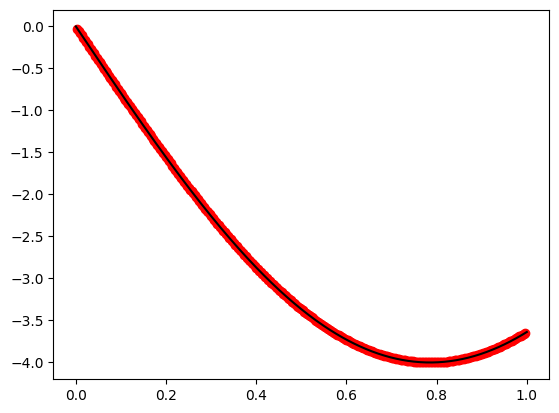

In [5]:
fig, ax = plt.subplots()
ax.plot(x_grid, -4.0 * np.sin(2*x_grid), color = 'k')
ax.scatter(x_grid[1:-1], (d2dx2 @ sin_vector)[1:-1], color = 'r')

In [6]:
H = -d2dx2 + 

In [7]:
N = 300
dt = 5.0e-6

t_grid = np.arange(N+1) * dt

In [13]:
A_num   = np.eye(N+1) - 1.0j * H * dt / 2
A_denom = np.eye(N+1) + 1.0j * H * dt / 2

In [14]:
A = np.linalg.solve(A_denom, A_num)

In [15]:
x0 = 0.5
sigma = 0.05
k = 100.0
psi0 = np.exp(-((x_grid - x0)**2) / (2 * sigma**2)) * np.exp(1.0j * k * x_grid)

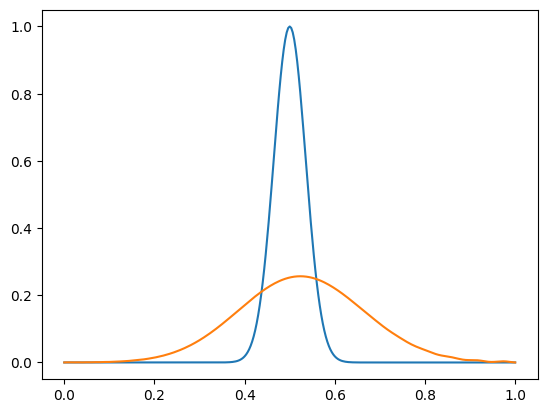

In [16]:
fig, ax = plt.subplots()
ax.plot(x_grid, np.abs(psi0)**2)

psi = np.copy(psi0)
for n in range(1000):
    psi = A @ psi

ax.plot(x_grid, np.abs(psi)**2)